# Part 4. Analysis and visualization
Author: **Abibulla Kundyz**

Input: `data/merged_dataset.csv`, `data/by_currency.csv`, `data/fx_rates_clean.csv` (from Part 3).

Questions:
1. How did currencies change against USD in 2015-2025?
2. Do bigger economies have more stable currencies?
3. Is GDP or inflation more connected to the loss of currency value?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/merged_dataset.csv")
by_currency = pd.read_csv("data/by_currency.csv")
fx = pd.read_csv("data/fx_rates_clean.csv").pivot(index="iso3", columns="year", values="rate_per_usd")
print(df.shape, by_currency.shape, fx.shape)

(166, 14) (99, 8) (167, 11)


## Descriptive statistics

In [2]:
cols = ["gdp_usd_bn", "value_change_pct", "volatility_pct", "max_yearly_drop_pct", "avg_inflation_pct"]
df[cols].describe().round(2)

,gdp_usd_bn,value_change_pct,volatility_pct,max_yearly_drop_pct,avg_inflation_pct
count,166.00,166.00,166.00,166.00,146.00
mean,528.85,-14.36,5.26,-12.00,4.89
std,1816.00,25.11,4.73,12.96,6.91
min,0.06,-99.26,0.00,-89.14,0.29
25%,10.45,-24.76,2.93,-11.62,1.99
50%,52.01,0.00,4.88,-10.97,2.80
75%,380.83,1.60,5.84,-5.68,4.74
max,20851.59,23.49,36.62,0.00,63.72


In [3]:
show = ["country", "income_level", "gdp_usd_bn", "value_change_pct", "avg_inflation_pct"]
print("lost the most:")
print(df.sort_values("value_change_pct").head(8)[show].round(1).to_string(index=False))
print()
print("gained the most:")
print(df.sort_values("value_change_pct", ascending=False).head(5)[show].round(1).to_string(index=False))

lost the most:
   country        income_level  gdp_usd_bn  value_change_pct  avg_inflation_pct
 Argentina Upper middle income       688.4             -99.3                NaN
   Lebanon Lower middle income        34.5             -98.3               63.7
    Turkey Upper middle income      1640.2             -93.1               28.1
  Suriname Upper middle income         5.9             -90.8               34.2
   Nigeria Lower middle income       377.4             -87.3               17.7
    Angola Lower middle income       152.4             -86.8               21.6
     Egypt Lower middle income       429.6             -84.4               16.1
Uzbekistan Lower middle income       181.5             -79.6               11.5

gained the most:
       country        income_level  gdp_usd_bn  value_change_pct  avg_inflation_pct
       Armenia Upper middle income        31.9              23.5                2.7
 Liechtenstein         High income         9.4              15.8               

In [4]:
weaker = (df["value_change_pct"] < 0).sum()
print("weaker vs USD:", weaker, "of", len(df))

# volatility close to 0 = currency is fixed to the dollar
pegged = df[df["volatility_pct"] < 0.5]
print("fixed to USD:", len(pegged), list(pegged["country"].head(6)))
not_pegged = df[df["volatility_pct"] >= 0.5]
print("weaker among the others:", round((not_pegged["value_change_pct"] < 0).mean() * 100), "%")

weaker vs USD: 81 of 166
fixed to USD: 24 ['Saudi Arabia', 'United Arab Emirates', 'Hong Kong', 'Qatar', 'Oman', 'Bolivia']
weaker among the others: 54 %


In [5]:
order = ["High income", "Upper middle income", "Lower middle income", "Low income"]
income = df.groupby("income_level")[["value_change_pct", "volatility_pct", "avg_inflation_pct"]].median()
income = income.loc[order]
income["n"] = df["income_level"].value_counts()
income.to_csv("data/income_group_summary.csv")
income.round(2)

,value_change_pct,volatility_pct,avg_inflation_pct,n
income_level,,,,
High income,1.60,4.88,2.23,71
Upper middle income,-13.01,4.88,3.63,48
Lower middle income,-26.39,4.92,4.60,34
Low income,1.60,4.92,2.89,13


## Correlations
We mostly use Spearman because there are big outliers (Argentina, Lebanon, Turkey), and Spearman works with ranks.
GDP is very uneven, so we use log10(GDP).

In [6]:
corr_cols = ["log10_gdp", "value_change_pct", "volatility_pct", "max_yearly_drop_pct", "avg_inflation_pct"]
spearman = df[corr_cols].corr(method="spearman")
pearson = df[corr_cols].corr(method="pearson")
spearman_cur = by_currency[corr_cols].corr(method="spearman")

result = pd.DataFrame({
    "spearman": spearman["log10_gdp"],
    "pearson": pearson["log10_gdp"],
    "spearman (by currency)": spearman_cur["log10_gdp"],
}).drop("log10_gdp")
spearman.to_csv("data/correlations_spearman.csv")
result.round(3)

,spearman,pearson,spearman (by currency)
value_change_pct,-0.044,-0.138,0.032
volatility_pct,0.216,0.174,0.143
max_yearly_drop_pct,-0.209,-0.182,-0.115
avg_inflation_pct,0.029,0.002,-0.159


In [7]:
print("inflation vs value change:", round(spearman.loc["avg_inflation_pct", "value_change_pct"], 2))
print("inflation vs volatility:  ", round(spearman.loc["avg_inflation_pct", "volatility_pct"], 2))

inflation vs value change: -0.65
inflation vs volatility:   0.52


## Plots
### 1. Distribution of the value change

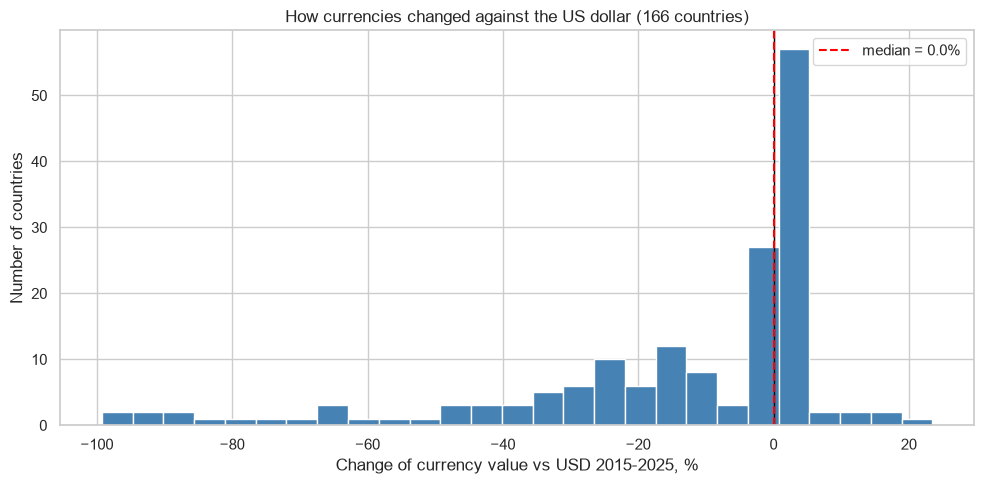

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df["value_change_pct"], bins=27, color="steelblue", edgecolor="white")
plt.axvline(0, color="black", linewidth=1)
plt.axvline(df["value_change_pct"].median(), color="red", linestyle="--",
            label="median = " + str(round(df["value_change_pct"].median(), 1)) + "%")
plt.xlabel("Change of currency value vs USD 2015-2025, %")
plt.ylabel("Number of countries")
plt.title("How currencies changed against the US dollar (" + str(len(df)) + " countries)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/1_value_change_hist.png", dpi=150)
plt.show()

Many countries are at 0 - these currencies are fixed to the dollar or euro. The rest mostly lost value, some almost 100%.

### 2. Currencies of big economies over time
2015 = 100. Lower than 100 means the currency became weaker.

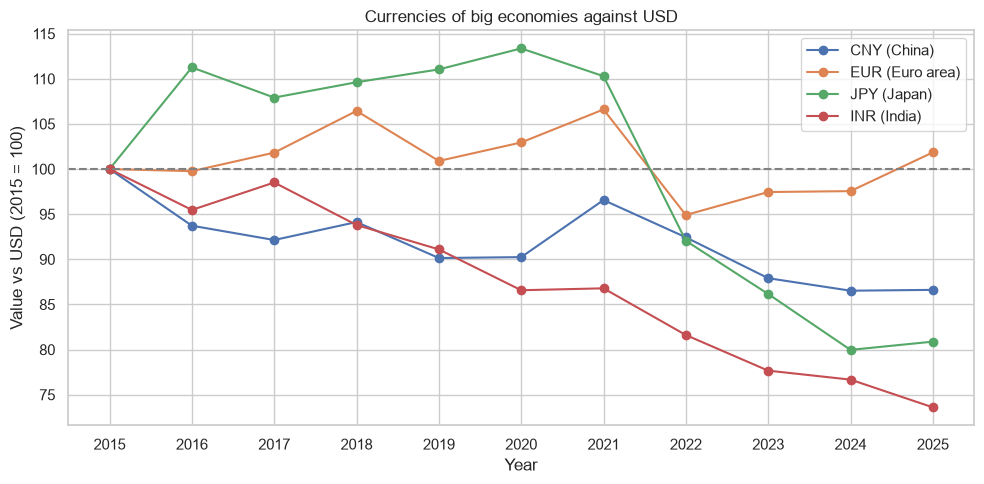

In [9]:
big = {"CHN": "CNY (China)", "DEU": "EUR (Euro area)", "JPN": "JPY (Japan)", "IND": "INR (India)"}

plt.figure(figsize=(10, 5))
for iso, label in big.items():
    value = 1 / fx.loc[iso]
    index = value / value[2015] * 100
    plt.plot(index.index, index.values, marker="o", label=label)
plt.axhline(100, color="gray", linestyle="--")
plt.xticks(range(2015, 2026))
plt.xlabel("Year")
plt.ylabel("Value vs USD (2015 = 100)")
plt.title("Currencies of big economies against USD")
plt.legend()
plt.tight_layout()
plt.savefig("figures/2_large_economies_index.png", dpi=150)
plt.show()

### 3. GDP vs value change and GDP vs volatility

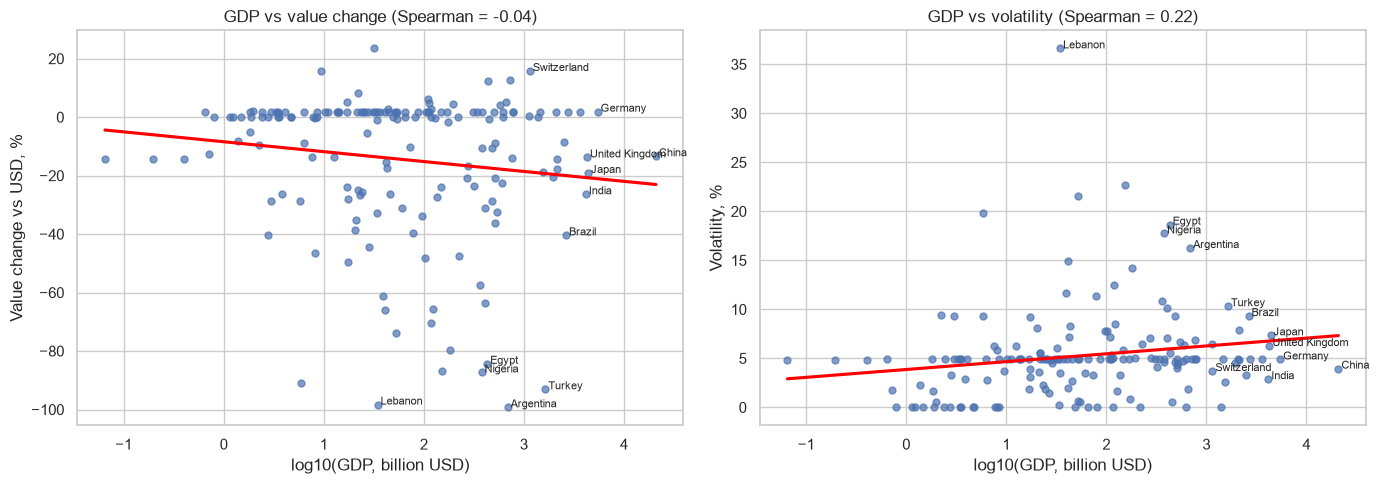

In [10]:
to_label = ["China", "Germany", "Japan", "India", "United Kingdom", "Brazil", "Turkey",
            "Argentina", "Switzerland", "Nigeria", "Egypt", "Lebanon"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, name, short in [(axes[0], "value_change_pct", "Value change vs USD, %", "value change"),
                             (axes[1], "volatility_pct", "Volatility, %", "volatility")]:
    sns.regplot(data=df, x="log10_gdp", y=col, ax=ax, ci=None,
                scatter_kws={"s": 25, "alpha": 0.7}, line_kws={"color": "red"})
    for _, row in df[df["country"].isin(to_label)].iterrows():
        ax.text(row["log10_gdp"] + 0.03, row[col], row["country"], fontsize=8)
    rho = spearman.loc["log10_gdp", col]
    ax.set_title("GDP vs " + short + " (Spearman = " + str(round(rho, 2)) + ")")
    ax.set_xlabel("log10(GDP, billion USD)")
    ax.set_ylabel(name)
plt.tight_layout()
plt.savefig("figures/3_gdp_scatter.png", dpi=150)
plt.show()

The line for value change is almost flat, so GDP does not really explain it. Volatility is even a bit higher for big economies -
small countries often fix their currency.

### 4. Inflation vs value change
Some countries have very high inflation, so the x axis is in log scale (symlog).

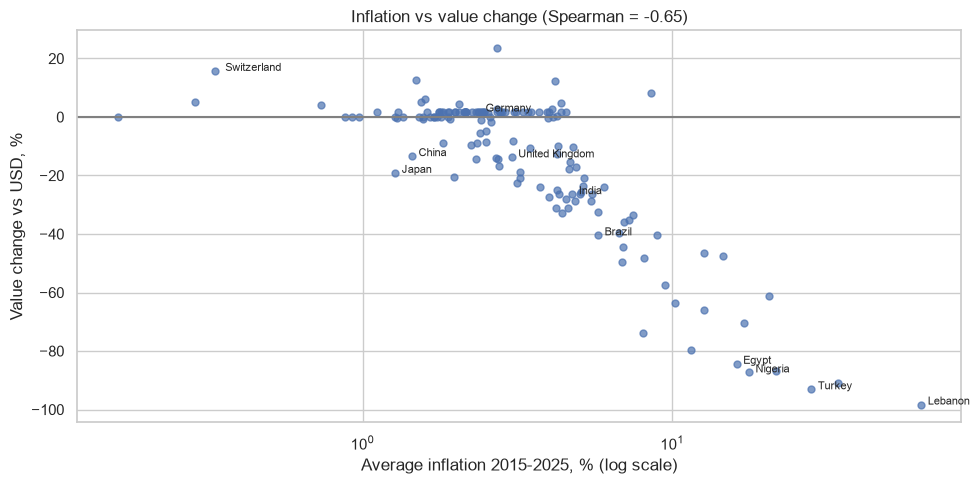

In [11]:
d = df.dropna(subset=["avg_inflation_pct"])

plt.figure(figsize=(10, 5))
plt.scatter(d["avg_inflation_pct"], d["value_change_pct"], s=25, alpha=0.7)
for _, row in d[d["country"].isin(to_label)].iterrows():
    plt.text(row["avg_inflation_pct"] * 1.05, row["value_change_pct"], row["country"], fontsize=8)
plt.xscale("symlog", linthresh=1)
plt.axhline(0, color="gray")
rho = spearman.loc["avg_inflation_pct", "value_change_pct"]
plt.title("Inflation vs value change (Spearman = " + str(round(rho, 2)) + ")")
plt.xlabel("Average inflation 2015-2025, % (log scale)")
plt.ylabel("Value change vs USD, %")
plt.tight_layout()
plt.savefig("figures/4_inflation_vs_change.png", dpi=150)
plt.show()

Here the connection is clear: higher inflation -> bigger loss of value.

### 5. Value change by income group

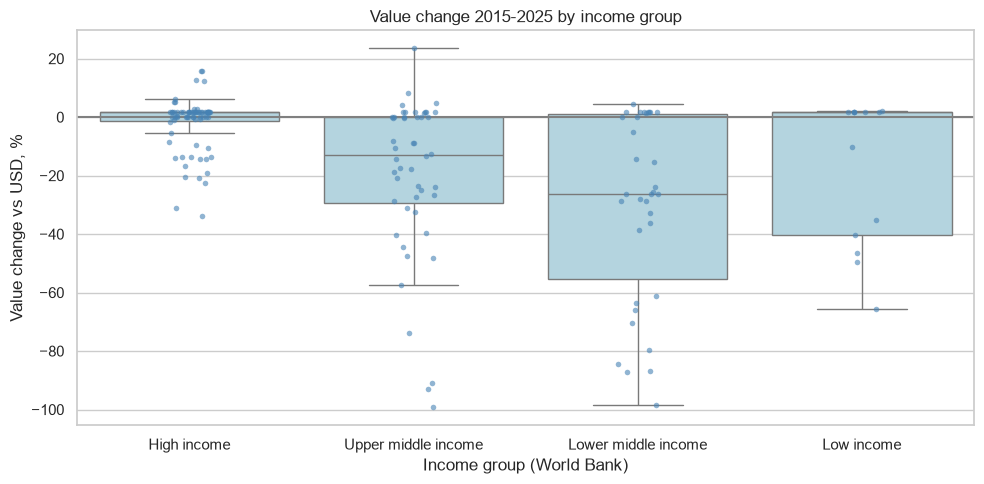

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="income_level", y="value_change_pct", order=order, color="lightblue", showfliers=False)
sns.stripplot(data=df, x="income_level", y="value_change_pct", order=order, color="steelblue", size=4, alpha=0.6)
plt.axhline(0, color="gray")
plt.xlabel("Income group (World Bank)")
plt.ylabel("Value change vs USD, %")
plt.title("Value change 2015-2025 by income group")
plt.tight_layout()
plt.savefig("figures/5_income_boxplot.png", dpi=150)
plt.show()

### 6. Correlation heatmap

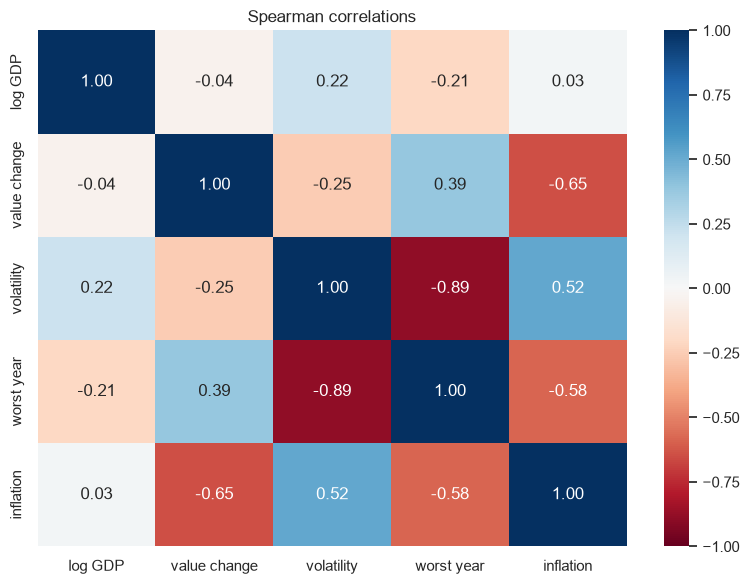

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu", vmin=-1, vmax=1,
            xticklabels=["log GDP", "value change", "volatility", "worst year", "inflation"],
            yticklabels=["log GDP", "value change", "volatility", "worst year", "inflation"])
plt.title("Spearman correlations")
plt.tight_layout()
plt.savefig("figures/6_correlation_heatmap.png", dpi=150)
plt.show()

## Conclusions

In [14]:
print("countries:", len(df), " currencies:", len(by_currency))
print("weaker vs USD:", round(weaker / len(df) * 100), "%")
print("GDP vs value change:", round(spearman.loc["log10_gdp", "value_change_pct"], 2))
print("GDP vs volatility:", round(spearman.loc["log10_gdp", "volatility_pct"], 2))
print("inflation vs value change:", round(spearman.loc["avg_inflation_pct", "value_change_pct"], 2))

countries: 166  currencies: 99
weaker vs USD: 49 %
GDP vs value change: -0.04
GDP vs volatility: 0.22
inflation vs value change: -0.65


1. About half of the currencies lost value against USD. Some lost almost everything: Argentina (-99%), Lebanon (-98%), Turkey (-93%), Nigeria (-87%), Egypt (-84%).
   The other half did not change much because they are fixed to the dollar (Gulf countries) or to the euro (CFA franc, Bulgaria, Denmark). The euro itself is about the same as in 2015.
2. The size of the economy is almost not connected with the value change (Spearman about -0.04).
3. Big economies even have a bit more volatile currencies (about +0.22), because many small countries fix their currency and big ones don't.
   So our idea "bigger economy = more stable currency" was wrong.
4. Inflation is much more important: Spearman about -0.65 with value change.
5. Lower middle income countries lost the most (median -26%). Low income looks stable only because many of them use the CFA franc.
6. If we count every currency only once, the results are almost the same.

**Limitations:** only yearly data; GDP is only for one year; some countries were removed; no inflation data for 20 countries (for example Argentina); correlation is not causation.